# Fase 1 — EDA y Preparación del Dataset PlantVillage
## Proyecto Final IA · EAFIT 2026-1
**Integrante 1 (P1):** EDA, visualizaciones, análisis de desbalance  
**Integrante 2 (P2):** Split train/val/test, DataLoaders, augmentation  

**Dataset:** PlantVillage — ~54,000 imágenes, 38 clases  
**Fuente:** https://www.kaggle.com/datasets/emmarex/plantdisease

---
> **Instrucciones para Colab:**
> 1. Ir a `Runtime → Change runtime type → GPU (T4)`
> 2. Ejecutar la celda de **Google Drive** primero (sección 0.1)
> 3. Ejecutar en orden hasta el final
> 4. Al terminar la fase, los artefactos quedan guardados en Drive → no se pierden si la sesión expira


## 0. Instalación de dependencias

## 0.1 Montar Google Drive (persistencia entre sesiones)

Todos los artefactos de salida se guardan automáticamente en **`Mi unidad/IA_EAFIT/`**.
Si la sesión de Colab expira y retoman el trabajo, solo monten Drive y los datos siguen ahí.

In [1]:
from google.colab import drive
from pathlib import Path
import os, shutil, json

drive.mount('/content/drive')

# ── Directorio raíz en Drive ─────────────────────────────────────────────────
DRIVE_DIR = Path('/content/drive/MyDrive/IA_EAFIT')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

# Subdirectorios
DRIVE_ARTIFACTS = DRIVE_DIR / 'artifacts'
DRIVE_FIGURES   = DRIVE_DIR / 'figures'
DRIVE_DATASET   = DRIVE_DIR / 'dataset'
for d in [DRIVE_ARTIFACTS, DRIVE_FIGURES, DRIVE_DATASET]:
    d.mkdir(exist_ok=True)

# ── Directorio local de trabajo ──────────────────────────────────────────────
ARTIFACTS = Path('/content/artifacts')
ARTIFACTS.mkdir(exist_ok=True)

print('✅ Google Drive montado')
print(f'   Raíz del proyecto : {DRIVE_DIR}')
print(f'   Artefactos        : {DRIVE_ARTIFACTS}')
print(f'   Figuras           : {DRIVE_FIGURES}')
print()
print('Contenido actual en Drive/IA_EAFIT/:')
items = list(DRIVE_DIR.rglob('*'))
if items:
    for item in sorted(items)[:20]:
        print(f'  {item.relative_to(DRIVE_DIR)}')
else:
    print('  (vacío — primera vez)')


Mounted at /content/drive
✅ Google Drive montado
   Raíz del proyecto : /content/drive/MyDrive/IA_EAFIT
   Artefactos        : /content/drive/MyDrive/IA_EAFIT/artifacts
   Figuras           : /content/drive/MyDrive/IA_EAFIT/figures

Contenido actual en Drive/IA_EAFIT/:
  artifacts
  dataset
  figures


### Función auxiliar: guardar artefactos en Drive

Esta función se usará al final de la fase para sincronizar todo a Drive de una sola vez.

In [2]:
def save_to_drive(local_path, subfolder='artifacts', verbose=True):
    """
    Copia un archivo local a Google Drive/IA_EAFIT/<subfolder>/.

    Args:
        local_path: Path o str del archivo en /content/
        subfolder:  'artifacts', 'figures', o 'dataset'
    Returns:
        Path de destino en Drive
    """
    local_path = Path(local_path)
    if not local_path.exists():
        print(f'  ⚠️  No encontrado: {local_path}')
        return None
    dest_dir = DRIVE_DIR / subfolder
    dest_dir.mkdir(exist_ok=True)
    dest = dest_dir / local_path.name
    shutil.copy2(local_path, dest)
    if verbose:
        size_kb = dest.stat().st_size / 1024
        print(f'  ✅ {local_path.name:40s} → Drive/{subfolder}/ ({size_kb:.1f} KB)')
    return dest


def load_from_drive(filename, subfolder='artifacts', dest_dir='/content/artifacts'):
    """
    Copia un archivo de Drive al entorno local de Colab.

    Args:
        filename:  Nombre del archivo en Drive/IA_EAFIT/<subfolder>/
        subfolder: 'artifacts', 'figures', o 'dataset'
        dest_dir:  Directorio local de destino
    Returns:
        Path local del archivo copiado, o None si no existe en Drive
    """
    src = DRIVE_DIR / subfolder / filename
    if not src.exists():
        print(f'  ⚠️  No encontrado en Drive: {src}')
        return None
    dest = Path(dest_dir)
    dest.mkdir(parents=True, exist_ok=True)
    dest_file = dest / filename
    shutil.copy2(src, dest_file)
    print(f'  ✅ {filename} cargado desde Drive → {dest_file}')
    return dest_file


print('✅ Funciones save_to_drive() y load_from_drive() listas')


✅ Funciones save_to_drive() y load_from_drive() listas


In [3]:
# Instalar dependencias necesarias para la Fase 1
!pip install -q kaggle matplotlib seaborn pandas Pillow torchvision torch tqdm
print('✅ Dependencias instaladas')

✅ Dependencias instaladas


## 1. Descarga del dataset desde Kaggle

**Pasos previos:**
1. Ir a https://www.kaggle.com → Account → API → `Create New Token`
2. Se descarga `kaggle.json` con tu API key
3. Subir ese archivo a Colab usando la celda de abajo

In [4]:
# Subir kaggle.json desde tu computador
from google.colab import files
import os

print('Sube tu archivo kaggle.json:')
uploaded = files.upload()

# Mover al directorio correcto
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ Kaggle API configurada')

Sube tu archivo kaggle.json:


Saving kaggle.json to kaggle.json
✅ Kaggle API configurada


In [5]:
# Descargar y descomprimir el dataset PlantVillage
!kaggle datasets download -d emmarex/plantdisease --unzip -p /content/plantvillage
print('✅ Dataset descargado en /content/plantvillage')

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 199MB/s]

✅ Dataset descargado en /content/plantvillage


In [6]:
import os
import pathlib

# Encontrar la ruta raíz del dataset (puede variar según la descarga)
BASE = pathlib.Path('/content/plantvillage')

# Buscar el directorio que contiene las carpetas de clases
# El dataset puede tener una carpeta intermedia 'PlantVillage' o 'plantvillage'
for root, dirs, files_list in os.walk(BASE):
    depth = root.replace(str(BASE), '').count(os.sep)
    if depth <= 2 and dirs:
        print(f"{'  ' * depth}{pathlib.Path(root).name}/")
        for d in sorted(dirs)[:5]:
            print(f"{'  ' * (depth+1)}{d}/")
        if len(dirs) > 5:
            print(f"{'  ' * (depth+1)}... y {len(dirs)-5} más")

plantvillage/
  PlantVillage/
  plantvillage/
  plantvillage/
    PlantVillage/
    PlantVillage/
      Pepper__bell___Bacterial_spot/
      Pepper__bell___healthy/
      Potato___Early_blight/
      Potato___Late_blight/
      Potato___healthy/
      ... y 10 más
  PlantVillage/
    Pepper__bell___Bacterial_spot/
    Pepper__bell___healthy/
    Potato___Early_blight/
    Potato___Late_blight/
    Potato___healthy/
    ... y 10 más


In [7]:
import pathlib

# ⚠️ AJUSTAR esta ruta según la salida de la celda anterior
# Opciones comunes:
#   DATA_ROOT = BASE / 'PlantVillage'
#   DATA_ROOT = BASE / 'plantvillage'
#   DATA_ROOT = BASE  (si las carpetas de clases están directamente aquí)

DATA_ROOT = BASE / 'PlantVillage'

# Verificar que las clases están accesibles
clases = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f'✅ Encontradas {len(clases)} clases en {DATA_ROOT}')
print('\nPrimeras 5 clases:')
for c in clases[:5]:
    print(f'  • {c}')

✅ Encontradas 15 clases en /content/plantvillage/PlantVillage

Primeras 5 clases:
  • Pepper__bell___Bacterial_spot
  • Pepper__bell___healthy
  • Potato___Early_blight
  • Potato___Late_blight
  • Potato___healthy


## 2. Análisis exploratorio de datos (EDA)
### 2.1 Estadísticas generales del dataset

In [8]:
import pandas as pd
from pathlib import Path

EXTENSIONS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# Construir DataFrame con clase → cantidad de imágenes
registros = []
for clase_dir in sorted(DATA_ROOT.iterdir()):
    if not clase_dir.is_dir():
        continue
    imagenes = [f for f in clase_dir.iterdir() if f.suffix in EXTENSIONS]
    n = len(imagenes)
    if n == 0:
        continue
    # Extraer planta y estado del nombre de la carpeta (formato: Planta___Estado)
    parts = clase_dir.name.split('___')
    planta = parts[0].replace('_', ' ') if len(parts) > 0 else clase_dir.name
    estado = parts[1].replace('_', ' ') if len(parts) > 1 else 'Desconocido'
    registros.append({
        'clase': clase_dir.name,
        'planta': planta,
        'estado': estado,
        'n_imagenes': n,
        'ruta': str(clase_dir)
    })

df = pd.DataFrame(registros).sort_values('n_imagenes', ascending=False).reset_index(drop=True)

total = df['n_imagenes'].sum()
n_clases = len(df)
n_plantas = df['planta'].nunique()

print('=' * 55)
print(f'  RESUMEN DEL DATASET PLANTVILLAGE')
print('=' * 55)
print(f'  Total de imágenes   : {total:,}')
print(f'  Total de clases     : {n_clases}')
print(f'  Plantas distintas   : {n_plantas}')
print(f'  Promedio por clase  : {total/n_clases:.0f} imágenes')
print(f'  Clase mayor         : {df.iloc[0]["clase"]} ({df.iloc[0]["n_imagenes"]:,})')
print(f'  Clase menor         : {df.iloc[-1]["clase"]} ({df.iloc[-1]["n_imagenes"]:,})')
print('=' * 55)

# Mostrar tabla completa
display(df[['planta', 'estado', 'n_imagenes']].rename(columns={
    'planta': 'Planta', 'estado': 'Estado', 'n_imagenes': 'Imágenes'
}))

  RESUMEN DEL DATASET PLANTVILLAGE
  Total de imágenes   : 20,638
  Total de clases     : 15
  Plantas distintas   : 12
  Promedio por clase  : 1376 imágenes
  Clase mayor         : Tomato__Tomato_YellowLeaf__Curl_Virus (3,208)
  Clase menor         : Potato___healthy (152)


,Planta,Estado,Imágenes
0,Tomato Tomato YellowLeaf Curl Virus,Desconocido,3208
1,Tomato Bacterial spot,Desconocido,2127
2,Tomato Late blight,Desconocido,1909
3,Tomato Septoria leaf spot,Desconocido,1771
4,Tomato Spider mites Two spotted spider mite,Desconocido,1676
5,Tomato healthy,Desconocido,1591
6,Pepper bell,healthy,1478
7,Tomato Target Spot,Desconocido,1404
8,Potato,Early blight,1000
9,Potato,Late blight,1000


### 2.2 Distribución de clases — análisis de desbalance

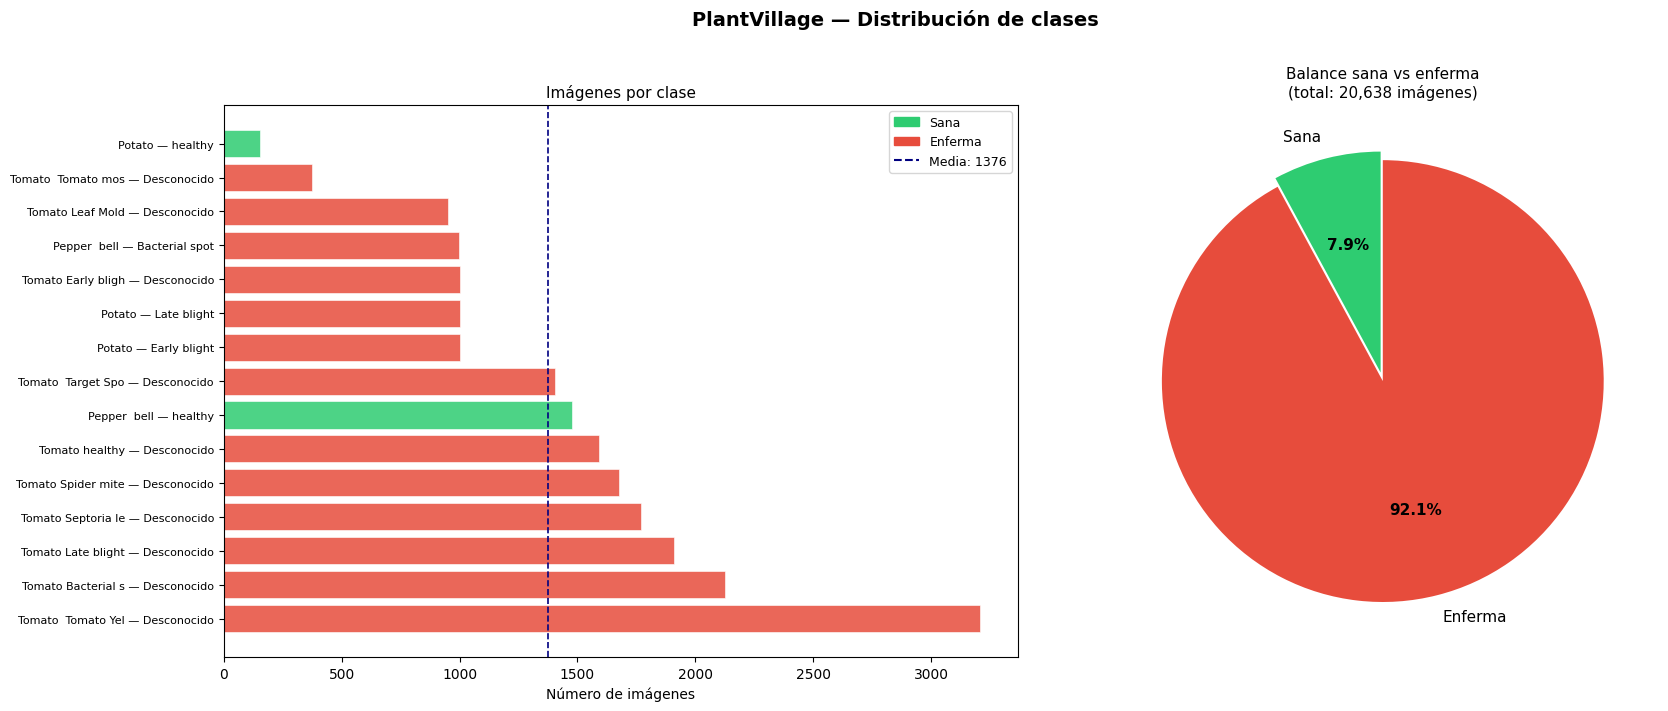

✅ Figura guardada: fig1_distribucion_clases.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('PlantVillage — Distribución de clases', fontsize=14, fontweight='bold', y=1.01)

# --- Gráfico 1: Barras por clase (todas) ---
ax1 = axes[0]
colores = ['#2ecc71' if 'healthy' in e.lower() else '#e74c3c'
           for e in df['estado']]
bars = ax1.barh(range(len(df)), df['n_imagenes'], color=colores, alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(df)))
ax1.set_yticklabels(
    [f"{r['planta'][:18]} — {r['estado'][:14]}" for _, r in df.iterrows()],
    fontsize=8
)
ax1.set_xlabel('Número de imágenes')
ax1.set_title('Imágenes por clase', fontsize=11)
ax1.axvline(df['n_imagenes'].mean(), color='navy', linestyle='--', linewidth=1.2,
            label=f'Media: {df["n_imagenes"].mean():.0f}')
ax1.legend(fontsize=9)
patch_h = mpatches.Patch(color='#2ecc71', label='Sana')
patch_e = mpatches.Patch(color='#e74c3c', label='Enferma')
ax1.legend(handles=[patch_h, patch_e, plt.Line2D([0],[0],color='navy',linestyle='--',label=f'Media: {df["n_imagenes"].mean():.0f}')],
           fontsize=9)

# --- Gráfico 2: Pie sana vs enferma ---
ax2 = axes[1]
sana = df[df['estado'].str.lower().str.contains('healthy')]['n_imagenes'].sum()
enferma = total - sana
wedges, texts, autotexts = ax2.pie(
    [sana, enferma],
    labels=['Sana', 'Enferma'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.04, 0),
    shadow=False,
    textprops={'fontsize': 11}
)
for t in autotexts:
    t.set_fontweight('bold')
ax2.set_title(f'Balance sana vs enferma\n(total: {total:,} imágenes)', fontsize=11)

plt.tight_layout()
plt.savefig('/content/fig1_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura guardada: fig1_distribucion_clases.png')

### 2.3 Selección de subconjunto de clases (recomendado para Colab)

Trabajar con las 38 clases tarda demasiado en Colab gratuito. Se seleccionan **8 clases representativas**: 4 cultivos × (sana + enferma).

In [11]:
# ── Selección de 8 clases representativas ──────────────────────────────────
# Puedes modificar esta lista según las clases disponibles en tu descarga.
# Formato esperado: nombre exacto de la carpeta dentro de DATA_ROOT

CLASES_OBJETIVO = [
    'Tomato_healthy',
    'Tomato_Late_blight',
    'Potato___healthy',
    'Potato___Late_blight',
    'Pepper__bell___healthy',
    'Pepper__bell___Bacterial_spot',
]

# Verificar cuáles existen realmente en el dataset descargado
clases_disponibles = set(c for c in clases)
clases_validas = [c for c in CLASES_OBJETIVO if c in clases_disponibles]
clases_faltantes = [c for c in CLASES_OBJETIVO if c not in clases_disponibles]

print(f'Clases objetivo: {len(CLASES_OBJETIVO)}')
print(f'Encontradas:     {len(clases_validas)}')
if clases_faltantes:
    print(f'\n⚠️  No encontradas (verifica el nombre exacto):')
    for c in clases_faltantes:
        print(f'   ✗ {c}')
    print('\nClases disponibles similares:')
    for cf in clases_faltantes:
        # Intenta encontrar una palabra clave en los nombres de clase disponibles
        # y muestra sugerencias si encuentra alguna
        palabra = cf.split('___')[0].replace('_', ' ').split('(')[0].strip().lower()
        similares = [s for s in clases_disponibles if palabra in s.lower()]
        if similares:
            for s in similares:
                print(f'   → {s}')
        else:
            print(f'   No hay clases similares para "{cf}"')

# Si alguna clase no existe, reemplazar con la más cercana disponible
# (ajustar manualmente si es necesario)
if not clases_validas:
    print('\n⚠️ No se encontró ninguna clase objetivo.')
    print('Usando las primeras 8 clases disponibles como fallback:')
    clases_validas = clases[:8]
    for c in clases_validas:
        print(f'  • {c}')
else:
    print(f'\n✅ Usando {len(clases_validas)} clases:')
    for c in clases_validas:
        n = len(list((DATA_ROOT / c).glob('*.*')))
        print(f'  • {c:50s} ({n:,} imgs)')

Clases objetivo: 6
Encontradas:     6

✅ Usando 6 clases:
  • Tomato_healthy                                     (1,591 imgs)
  • Tomato_Late_blight                                 (1,909 imgs)
  • Potato___healthy                                   (152 imgs)
  • Potato___Late_blight                               (1,000 imgs)
  • Pepper__bell___healthy                             (1,478 imgs)
  • Pepper__bell___Bacterial_spot                      (997 imgs)


### 2.4 Visualización de ejemplos por clase

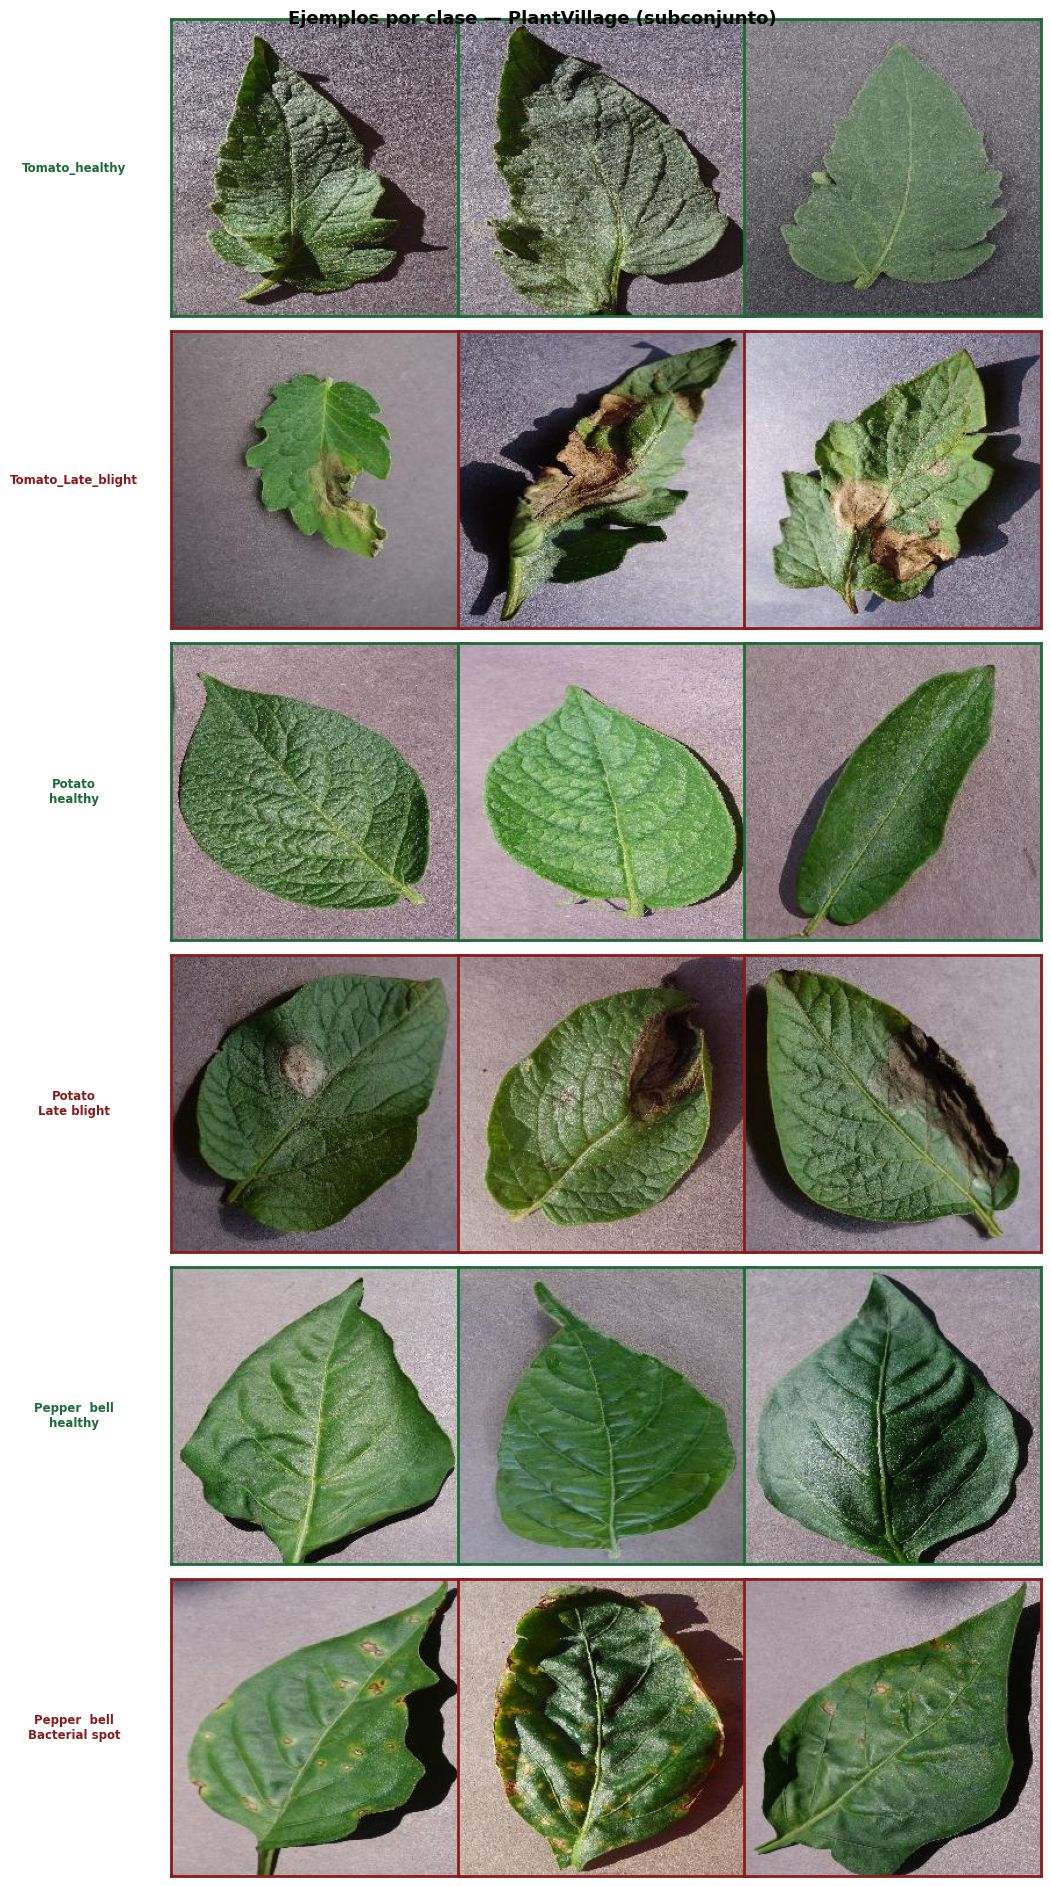

✅ Figura guardada: fig2_ejemplos_por_clase.png


In [12]:
import random
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)

n_clases_viz = len(clases_validas)
cols = 3  # imágenes por clase
fig, axes = plt.subplots(n_clases_viz, cols, figsize=(cols * 3.5, n_clases_viz * 3.2))
fig.suptitle('Ejemplos por clase — PlantVillage (subconjunto)', fontsize=13, fontweight='bold')

if n_clases_viz == 1:
    axes = [axes]

for fila, clase in enumerate(clases_validas):
    clase_path = DATA_ROOT / clase
    imgs = list(clase_path.glob('*.JPG')) + list(clase_path.glob('*.jpg')) + \
           list(clase_path.glob('*.png')) + list(clase_path.glob('*.PNG')) + \
           list(clase_path.glob('*.jpeg'))

    muestra = random.sample(imgs, min(cols, len(imgs)))

    # Etiqueta limpia
    parts = clase.split('___')
    label = f"{parts[0].replace('_', ' ')}\n{parts[1].replace('_', ' ')}" if len(parts) > 1 else clase
    color_label = '#1a6b35' if 'healthy' in clase.lower() else '#8b1a1a'

    for col_idx in range(cols):
        ax = axes[fila][col_idx] if cols > 1 else axes[fila]
        if col_idx < len(muestra):
            try:
                img = Image.open(muestra[col_idx]).convert('RGB')
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        else:
            ax.axis('off')
            continue

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(color_label)
            spine.set_linewidth(2)

        if col_idx == 0:
            ax.set_ylabel(label, fontsize=8.5, color=color_label,
                          fontweight='bold', rotation=0, labelpad=70, va='center')

plt.tight_layout()
plt.savefig('/content/fig2_ejemplos_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figura guardada: fig2_ejemplos_por_clase.png')

### 2.5 Análisis de propiedades de las imágenes

/tmp/ipykernel_7497/1302275695.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


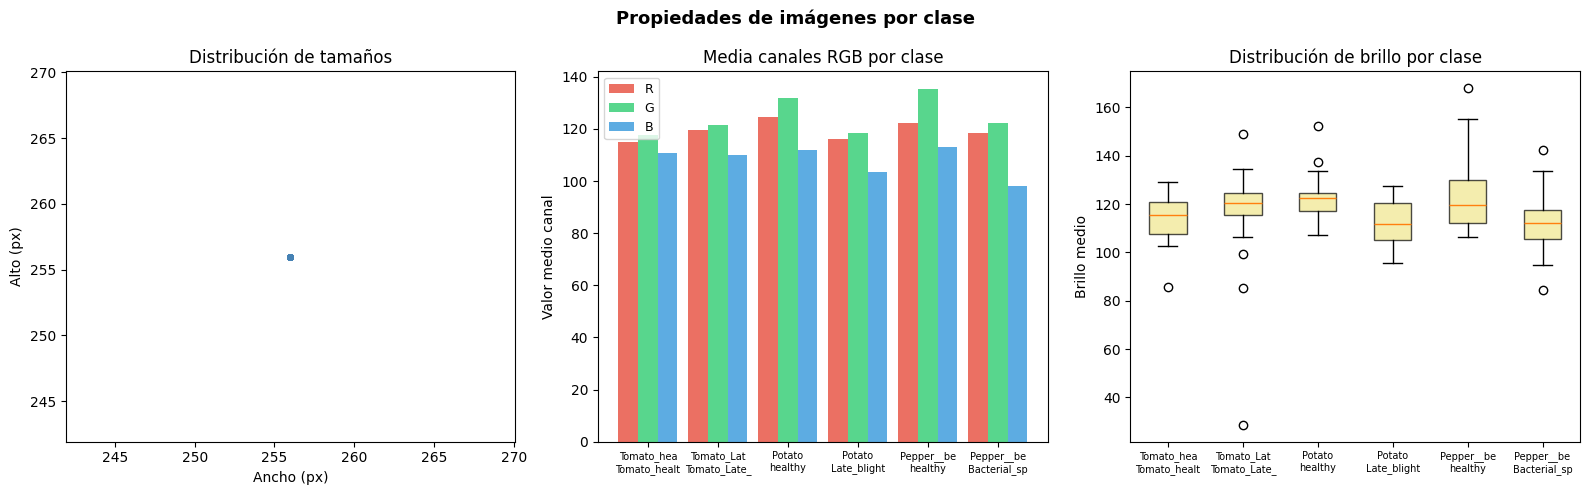


📐 TAMAÑOS DE IMAGEN:
  Tamaño más frecuente: 256×256 px
  Todos del mismo tamaño: True
  Min ancho: 256 | Max ancho: 256
✅ Figura guardada: fig3_propiedades_imagenes.png


In [13]:
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
N_MUESTRA = 30  # imágenes a analizar por clase (más = más lento)

props = []
for clase in clases_validas:
    clase_path = DATA_ROOT / clase
    imgs = list(clase_path.glob('*.JPG')) + list(clase_path.glob('*.jpg')) + \
           list(clase_path.glob('*.png')) + list(clase_path.glob('*.PNG'))
    muestra = random.sample(imgs, min(N_MUESTRA, len(imgs)))
    for p in muestra:
        try:
            img = Image.open(p).convert('RGB')
            arr = np.array(img)
            props.append({
                'clase': clase,
                'ancho': img.width,
                'alto': img.height,
                'r_mean': arr[:,:,0].mean(),
                'g_mean': arr[:,:,1].mean(),
                'b_mean': arr[:,:,2].mean(),
                'brillo': arr.mean()
            })
        except Exception:
            pass

df_props = pd.DataFrame(props)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Propiedades de imágenes por clase', fontsize=13, fontweight='bold')

# Tamaños
axes[0].scatter(df_props['ancho'], df_props['alto'], alpha=0.4, s=15, color='steelblue')
axes[0].set_xlabel('Ancho (px)')
axes[0].set_ylabel('Alto (px)')
axes[0].set_title('Distribución de tamaños')

# Canales RGB por clase
clases_cortas = [c.split('___')[0][:10] + '\n' + c.split('___')[-1][:12]
                 for c in clases_validas]
r_med = [df_props[df_props['clase']==c]['r_mean'].mean() for c in clases_validas]
g_med = [df_props[df_props['clase']==c]['g_mean'].mean() for c in clases_validas]
b_med = [df_props[df_props['clase']==c]['b_mean'].mean() for c in clases_validas]
x = np.arange(len(clases_validas))
w = 0.28
axes[1].bar(x - w, r_med, w, label='R', color='#e74c3c', alpha=0.8)
axes[1].bar(x,     g_med, w, label='G', color='#2ecc71', alpha=0.8)
axes[1].bar(x + w, b_med, w, label='B', color='#3498db', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(clases_cortas, fontsize=7)
axes[1].set_ylabel('Valor medio canal')
axes[1].set_title('Media canales RGB por clase')
axes[1].legend(fontsize=9)

# Brillo
axes[2].boxplot(
    [df_props[df_props['clase']==c]['brillo'].values for c in clases_validas],
    labels=clases_cortas,
    patch_artist=True,
    boxprops=dict(facecolor='#f0e68c', alpha=0.7)
)
axes[2].set_ylabel('Brillo medio')
axes[2].set_title('Distribución de brillo por clase')
axes[2].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig('/content/fig3_propiedades_imagenes.png', dpi=120, bbox_inches='tight')
plt.show()

# Estadísticas clave
print('\n📐 TAMAÑOS DE IMAGEN:')
print(f'  Tamaño más frecuente: {df_props["ancho"].mode()[0]}×{df_props["alto"].mode()[0]} px')
print(f'  Todos del mismo tamaño: {(df_props["ancho"].nunique() == 1 and df_props["alto"].nunique() == 1)}')
print(f'  Min ancho: {df_props["ancho"].min()} | Max ancho: {df_props["ancho"].max()}')
print('✅ Figura guardada: fig3_propiedades_imagenes.png')

## 3. Preparación del Dataset — Split y DataLoaders
### 3.1 Copiar subconjunto y crear estructura train/val/test

In [14]:
import shutil
import random
from pathlib import Path
from collections import defaultdict

random.seed(42)

SPLIT_DIR = Path('/content/dataset_split')
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15  # = 1 - TRAIN - VAL

# Crear estructura de directorios
for split in ['train', 'val', 'test']:
    for clase in clases_validas:
        (SPLIT_DIR / split / clase).mkdir(parents=True, exist_ok=True)

conteo = defaultdict(lambda: defaultdict(int))

for clase in clases_validas:
    clase_path = DATA_ROOT / clase
    imagenes = sorted([
        f for f in clase_path.iterdir()
        if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
    ])
    random.shuffle(imagenes)

    n = len(imagenes)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits_asignados = {
        'train': imagenes[:n_train],
        'val':   imagenes[n_train:n_train + n_val],
        'test':  imagenes[n_train + n_val:]
    }

    for split_name, archivos in splits_asignados.items():
        for archivo in archivos:
            dest = SPLIT_DIR / split_name / clase / archivo.name
            if not dest.exists():  # evitar recopia si ya existe
                shutil.copy2(archivo, dest)
        conteo[clase][split_name] = len(archivos)

# Resumen del split
print(f'Split completado — random_state=42')
print(f'{"Clase":<50} {"Train":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
print('-' * 75)
totales = {'train': 0, 'val': 0, 'test': 0}
for clase in clases_validas:
    tr = conteo[clase]['train']
    va = conteo[clase]['val']
    te = conteo[clase]['test']
    print(f'{clase:<50} {tr:>6} {va:>6} {te:>6} {tr+va+te:>7}')
    totales['train'] += tr; totales['val'] += va; totales['test'] += te
print('-' * 75)
total_final = sum(totales.values())
print(f'{"TOTAL":<50} {totales["train"]:>6} {totales["val"]:>6} {totales["test"]:>6} {total_final:>7}')
print(f'\nPorcentajes: Train={100*totales["train"]/total_final:.1f}% | Val={100*totales["val"]/total_final:.1f}% | Test={100*totales["test"]/total_final:.1f}%')
print(f'\n✅ Dataset dividido en {SPLIT_DIR}')

Split completado — random_state=42
Clase                                               Train    Val   Test   Total
---------------------------------------------------------------------------
Tomato_healthy                                       1113    238    240    1591
Tomato_Late_blight                                   1336    286    287    1909
Potato___healthy                                      106     22     24     152
Potato___Late_blight                                  700    150    150    1000
Pepper__bell___healthy                               1034    221    223    1478
Pepper__bell___Bacterial_spot                         697    149    151     997
---------------------------------------------------------------------------
TOTAL                                                4986   1066   1075    7127

Porcentajes: Train=70.0% | Val=15.0% | Test=15.1%

✅ Dataset dividido en /content/dataset_split


### 3.2 Transformaciones y Data Augmentation

In [15]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Hiperparámetros
IMG_SIZE   = 224   # requerido por ResNet-50 / EfficientNet
BATCH_SIZE = 32
NUM_WORKERS = 2

# ── Estadísticas ImageNet (usadas para normalizar con modelos preentrenados) ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transformaciones ─────────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # resize un poco más grande
    transforms.RandomCrop(IMG_SIZE),                    # crop aleatorio
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.05
    ),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_val_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # sin augmentation para val/test
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Datasets ─────────────────────────────────────────────────────────────────
dataset_train = datasets.ImageFolder(SPLIT_DIR / 'train', transform=transform_train)
dataset_val   = datasets.ImageFolder(SPLIT_DIR / 'val',   transform=transform_val_test)
dataset_test  = datasets.ImageFolder(SPLIT_DIR / 'test',  transform=transform_val_test)

# ── DataLoaders ───────────────────────────────────────────────────────────────
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Mapa de clases (índice → nombre)
CLASS_NAMES = dataset_train.classes
IDX_TO_CLASS = {v: k for k, v in dataset_train.class_to_idx.items()}

print('DataLoaders creados correctamente')
print(f'  Clases ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'  Train batches : {len(loader_train)}')
print(f'  Val   batches : {len(loader_val)}')
print(f'  Test  batches : {len(loader_test)}')

# Verificar forma de un batch
imgs, labels = next(iter(loader_train))
print(f'\nForma de un batch de imágenes: {imgs.shape}  (B × C × H × W)')
print(f'Forma de etiquetas:             {labels.shape}')
print(f'dtype imágenes: {imgs.dtype} | rango: [{imgs.min():.2f}, {imgs.max():.2f}]')

DataLoaders creados correctamente
  Clases (6): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Late_blight', 'Tomato_healthy']
  Train batches : 156
  Val   batches : 34
  Test  batches : 34

Forma de un batch de imágenes: torch.Size([32, 3, 224, 224])  (B × C × H × W)
Forma de etiquetas:             torch.Size([32])
dtype imágenes: torch.float32 | rango: [-2.12, 2.64]


### 3.3 Visualizar augmentation aplicada

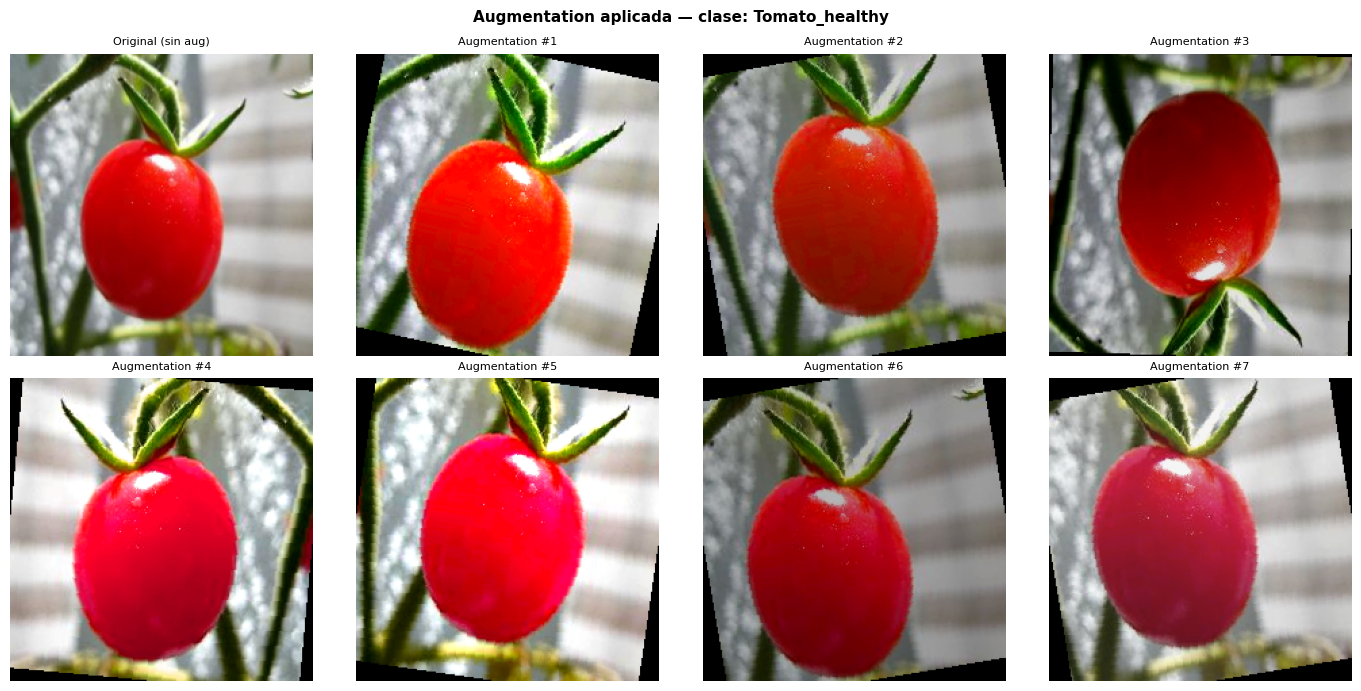

✅ Figura guardada: fig4_augmentation.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Revertir normalización ImageNet para visualizar."""
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

# Tomar una sola imagen y aplicar augmentation 8 veces
img_raw_path = list((SPLIT_DIR / 'train' / clases_validas[0]).glob('*.jpg'))[0]
from PIL import Image as PILImage

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(f'Augmentation aplicada — clase: {clases_validas[0]}', fontsize=11, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img_pil = PILImage.open(img_raw_path).convert('RGB')
    if i == 0:
        # Primera imagen sin augmentation
        t = transform_val_test(img_pil)
        ax.set_title('Original (sin aug)', fontsize=8)
    else:
        t = transform_train(img_pil)
        ax.set_title(f'Augmentation #{i}', fontsize=8)
    img_show = denormalize(t).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/fig4_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figura guardada: fig4_augmentation.png')

## 4. Calcular media y desviación del dataset de entrenamiento

Opcionalmente se pueden calcular las estadísticas del dataset propio en lugar de usar ImageNet.

In [17]:
# Calcular mean/std del conjunto de entrenamiento (sin normalización)
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch

transform_raw = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
ds_raw = datasets.ImageFolder(SPLIT_DIR / 'train', transform=transform_raw)
loader_raw = DataLoader(ds_raw, batch_size=64, shuffle=False, num_workers=2)

mean = torch.zeros(3)
std  = torch.zeros(3)
n_samples = 0

for imgs, _ in loader_raw:
    b = imgs.size(0)
    imgs = imgs.view(b, 3, -1)          # (B, 3, H*W)
    mean += imgs.mean(dim=2).sum(dim=0)
    std  += imgs.std(dim=2).sum(dim=0)
    n_samples += b

mean /= n_samples
std  /= n_samples

print('Estadísticas del dataset de entrenamiento (propias):')
print(f'  Mean : {mean.tolist()}')
print(f'  Std  : {std.tolist()}')
print()
print('Estadísticas ImageNet (referencia):')
print(f'  Mean : {IMAGENET_MEAN}')
print(f'  Std  : {IMAGENET_STD}')
print()
print('💡 Si los valores son cercanos a ImageNet, usar ImageNet es completamente válido.')

Estadísticas del dataset de entrenamiento (propias):
  Mean : [0.4607248306274414, 0.4797769784927368, 0.4187224805355072]
  Std  : [0.17032422125339508, 0.14734326303005219, 0.18431496620178223]

Estadísticas ImageNet (referencia):
  Mean : [0.485, 0.456, 0.406]
  Std  : [0.229, 0.224, 0.225]

💡 Si los valores son cercanos a ImageNet, usar ImageNet es completamente válido.


## 5. Guardar objetos para las siguientes fases

In [18]:
import json
from pathlib import Path

ARTIFACTS.mkdir(exist_ok=True)

# ── Guardar config local ─────────────────────────────────────────────────────
config = {
    'clases'         : clases_validas,
    'class_names'    : CLASS_NAMES,
    'idx_to_class'   : IDX_TO_CLASS,
    'split_dir'      : str(SPLIT_DIR),
    'img_size'       : IMG_SIZE,
    'batch_size'     : BATCH_SIZE,
    'imagenet_mean'  : IMAGENET_MEAN,
    'imagenet_std'   : IMAGENET_STD,
    'n_clases'       : len(clases_validas),
    'totales_split'  : totales
}
with open(ARTIFACTS / 'config_fase1.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# ── Sincronizar a Google Drive ───────────────────────────────────────────────
print('Guardando artefactos en Google Drive...')
save_to_drive(ARTIFACTS / 'config_fase1.json', subfolder='artifacts')

print()
print('Guardando figuras en Google Drive...')
for fig in ['fig1_distribucion_clases', 'fig2_ejemplos_por_clase',
            'fig3_propiedades_imagenes', 'fig4_augmentation']:
    save_to_drive(f'/content/{fig}.png', subfolder='figures')

# ── Zip del dataset dividido (solo la primera vez — puede tardar ~2 min) ────
import zipfile
ZIP_PATH = ARTIFACTS / 'dataset_split.zip'
if not (DRIVE_DATASET / 'dataset_split.zip').exists():
    print()
    print('Comprimiendo dataset_split/ para Drive (primera vez, ~2 min)...')
    with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
        for file in sorted(SPLIT_DIR.rglob('*')):
            if file.is_file():
                zf.write(file, file.relative_to(SPLIT_DIR.parent))
    save_to_drive(ZIP_PATH, subfolder='dataset')
    print('  ✅ dataset_split.zip guardado en Drive (no se repetirá)')
else:
    print()
    print('  ℹ️  dataset_split.zip ya existe en Drive — no se repite')

print()
print('━' * 55)
print('  FASE 1 COMPLETADA ✅')
print('━' * 55)
print(f'  Dataset       : PlantVillage (subconjunto)')
print(f'  Clases        : {len(clases_validas)}')
print(f'  Total imgs    : {sum(totales.values()):,}')
print(f'  Split         : 70 / 15 / 15')
print(f'  IMG_SIZE      : {IMG_SIZE}×{IMG_SIZE}')
print(f'  BATCH_SIZE    : {BATCH_SIZE}')
print()
print('  Artefactos en Drive/IA_EAFIT/:')
print('    artifacts/config_fase1.json')
print('    figures/fig1..fig4.png')
print('    dataset/dataset_split.zip')
print()
print('  Siguiente paso → Fase 2: CNN con Transfer Learning')


Guardando artefactos en Google Drive...
  ✅ config_fase1.json                        → Drive/artifacts/ (0.9 KB)

Guardando figuras en Google Drive...
  ✅ fig1_distribucion_clases.png             → Drive/figures/ (146.1 KB)
  ✅ fig2_ejemplos_por_clase.png              → Drive/figures/ (3971.0 KB)
  ✅ fig3_propiedades_imagenes.png            → Drive/figures/ (68.2 KB)
  ✅ fig4_augmentation.png                    → Drive/figures/ (1276.8 KB)

Comprimiendo dataset_split/ para Drive (primera vez, ~2 min)...
  ✅ dataset_split.zip                        → Drive/dataset/ (120847.8 KB)
  ✅ dataset_split.zip guardado en Drive (no se repetirá)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FASE 1 COMPLETADA ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset       : PlantVillage (subconjunto)
  Clases        : 6
  Total imgs    : 7,127
  Split         : 70 / 15 / 15
  IMG_SIZE      : 224×224
  BATCH_SIZE    : 32

  Artefactos en Drive/IA_EAFIT/:
    artifacts/config_f

## Resumen para el informe (Sección 2 — Datos y EDA)

Completa esta tabla con los valores obtenidos arriba para incluirla en el LaTeX:

| Atributo | Descripción |
|---|---|
| **Fuente** | Kaggle — emmarex/plantdisease |
| **Registros (N)** | 7,127 imágenes |
| **Clases** | 6 clases (sanas + enfermas) |
| **Cultivos** | 3 cultivos distintos |
| **Variable objetivo** | Clase de enfermedad (multiclase) |
| **Tamaño de imagen** | 256×256 px (original) → 224×224 (modelo) |
| **Split** | 70% train / 15% val / 15% test (random_state=42) |
| **Augmentation** | RandomCrop, HFlip, VFlip, ColorJitter, Rotation±15° |
| **Normalización** | Media/std ImageNet ([0.485,0.456,0.406] / [0.229,0.224,0.225]) |

### Hallazgos del EDA a mencionar en el informe:
1. **Desbalance de clases**: algunas enfermedades tienen significativamente más imágenes que otras — revisar fig1.
2. **Uniformidad de tamaños**: PlantVillage ya viene preprocesado a tamaño uniforme (256×256), lo que simplifica el pipeline.
3. **Diferencias de color**: las clases enfermas presentan tonos más amarillos/marrones vs. verdes intensos en clases sanas — visible en el análisis RGB (fig3).
4. **Fondo**: las imágenes tienen dos versiones (con/sin fondo). El subconjunto de Kaggle suele incluir ambas — anotarlo.